# C11 · Who needs the second drug? Hidden subgroups with their own regressions

| | |
|---|---|
| **Difficulty** | ★★★★★ |
| **Time** | 5-6 hours |
| **Data** | AIDS Clinical Trials Group Study 175 (Hammer et al. 1996): 1054 HIV-infected adults randomised to zidovudine alone or zidovudine + didanosine, CD4 counts at baseline and 20 weeks |
| **Skills** | Mixtures of regressions · truncated Dirichlet-process (stick-breaking) priors on subgroups · marginalised assignments · label-free diagnostics · spotting an analysis that peeks at the outcome · covariate-dependent mixture weights (logistic stick-breaking) · what LOO can and cannot see · conditional treatment effects and a treatment rule with uncertainty |

## The brief

It is 1996. ACTG 175 has just shown that adding **didanosine (ddI)** to zidovudine (ZDV)
slows HIV disease better than ZDV alone. But ddI is not free: it causes pancreatitis and
painful peripheral neuropathy in a minority of patients, and a clinic has to decide *whom*
to put on the combination. The HIV clinic you work for asks:

> "Does everybody benefit, or is there a subgroup of patients for whom ddI does little and
> who could be spared the toxicity? Our rule of thumb: ddI is worth it for a patient if it
> raises their CD4 count after 20 weeks by **at least 15%**, and we want to be at least
> **80% sure** of that."

A statistician on the team has already fitted a "clustering regression" and says it found
**responders and non-responders**. Your job: build the model properly - a regression whose
coefficients may differ between hidden subgroups, with a Dirichlet-process prior so that
the data decide how many subgroups there are - find out what it can and cannot say about
*who* benefits, and turn it into a rule the clinic can use.

This is the regression sequel to example **E26** (Dirichlet-process mixtures of *densities*).
Do E26 first: this challenge assumes you know stick-breaking, truncation checks and why
component labels are meaningless.

## How this notebook works

- Each task states **what to deliver**, not how. Write your code in the `YOUR CODE HERE` cells.
- Stuck? `h.hint("task3")` reveals hints one level at a time: *nudge → approach → code skeleton*.
  Try to get by on nudges.
- `h.check("task2", ate=...)` compares your numbers with the reference solution.
- A full worked solution lives in `notebooks/solutions/`. Open it only when you are done (or truly stuck).

In [1]:
import logging
import time

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import pytensor.tensor as pt
import xarray as xr
from scipy import stats

from pymc_challenges import Hints, data

RANDOM_SEED = 1996
rng = np.random.default_rng(RANDOM_SEED)
az.style.use("arviz-variat")
logging.getLogger("pymc").setLevel(logging.WARNING)  # several fits: no sampler banner per fit

h = Hints("C11")
h.tasks()

**C11 - Who needs the second drug? Hidden subgroups with their own regressions**

- `task0` - Look at the trial (2 hints)
- `task1` - One regression for everybody (3 hints, 2 check(s))
- `task2` - A Dirichlet-process mixture of regressions (3 hints, 2 check(s))
- `task3` - The colleague's responder list (3 hints, 2 check(s))
- `task4` - Let the baseline profile choose the subgroup (3 hints, 2 check(s))
- `task5` - The clinic's rule (3 hints, 3 check(s))

## The data

One row per patient. We use the two arms the clinic is choosing between: `trt = 0`
(zidovudine alone) and `trt = 1` (zidovudine + didanosine). CD4 cells are the immune cells
HIV destroys; their count per mm³ of blood is the standard marker of disease progression
(below 200 means AIDS). The trial enrolled patients with 200-500 cells/mm³.

| column | meaning |
|---|---|
| `cd40`, `cd420` | CD4 count at baseline and at 20 ± 5 weeks - **the outcome is `cd420`** |
| `cd80`, `cd820` | CD8 count at baseline and 20 weeks (do not use `cd820`: it is post-treatment) |
| `age`, `wtkg` | age (years), weight (kg) |
| `str2` | prior antiretroviral therapy (1 = experienced, 0 = naive) |
| `symptom` | 1 = symptomatic HIV infection at baseline |
| `karnof` | Karnofsky performance score (100 = normal activity) |
| `gender`, `race` | 1 = male; 1 = non-white |
| `homo`, `drugs`, `hemo` | homosexual activity, injection drug use, haemophilia (1 = yes) |
| `offtrt`, `time`, `cid` | post-randomisation: stopped treatment, follow-up days, clinical event - do not use |

In [2]:
data.describe("actg175")
actg = data.load("actg175")
trial = actg[actg.trt.isin([0, 1])].copy()
print(trial.trt.value_counts().sort_index().rename({0: "ZDV", 1: "ZDV + ddI"}))
trial.describe().T.round(1)

actg175: 2139 HIV-infected adults with 200-500 CD4 cells/mm3, randomised to zidovudine (ZDV, trt 0), ZDV + didanosine (trt 1), ZDV + zalcitabine (trt 2) or didanosine alone (trt 3). One row per patient: baseline covariates (age, wtkg, hemo, homo, drugs, karnof, race, gender, str2 = prior antiretroviral therapy, symptom, ...), CD4/CD8 counts at baseline (cd40, cd80) and at 20 +- 5 weeks (cd420, cd820), and time to a clinical event (time, cid).
  source: Hammer et al. (1996, New England Journal of Medicine 335:1081), AIDS Clinical Trials Group Study 175; UCI Machine Learning Repository dataset 890 (doi:10.24432/C5ZG8F), the same data as the R package `speff2trial` (Juraska et al.).
  url:    https://archive.ics.uci.edu/static/public/890/data.csv
trt
ZDV          532
ZDV + ddI    522
Name: count, dtype: int64


,count,mean,std,min,25%,50%,75%,max
cid,1054.0,0.3,0.4,0.0,0.0,0.0,1.0,1.0
time,1054.0,858.2,302.9,33.0,647.2,989.0,1090.0,1231.0
trt,1054.0,0.5,0.5,0.0,0.0,0.0,1.0,1.0
age,1054.0,35.2,8.8,12.0,29.0,34.0,40.0,70.0
wtkg,1054.0,75.5,13.4,31.0,67.1,74.5,83.0,159.9
hemo,1054.0,0.1,0.3,0.0,0.0,0.0,0.0,1.0
homo,1054.0,0.7,0.5,0.0,0.0,1.0,1.0,1.0
drugs,1054.0,0.1,0.3,0.0,0.0,0.0,0.0,1.0
karnof,1054.0,95.5,5.9,70.0,90.0,100.0,100.0,100.0
oprior,1054.0,0.0,0.2,0.0,0.0,0.0,0.0,1.0


## Task 0 · Look at the trial

**Deliver**
1. A plot of CD4 at 20 weeks against baseline CD4, by arm, on the scale you will model.
   Why that scale?
2. The records that cannot be right, and what you do with them.
3. The distribution of the change from baseline in each arm: centre, spread, and shape.
   What would a regression's error distribution have to look like?

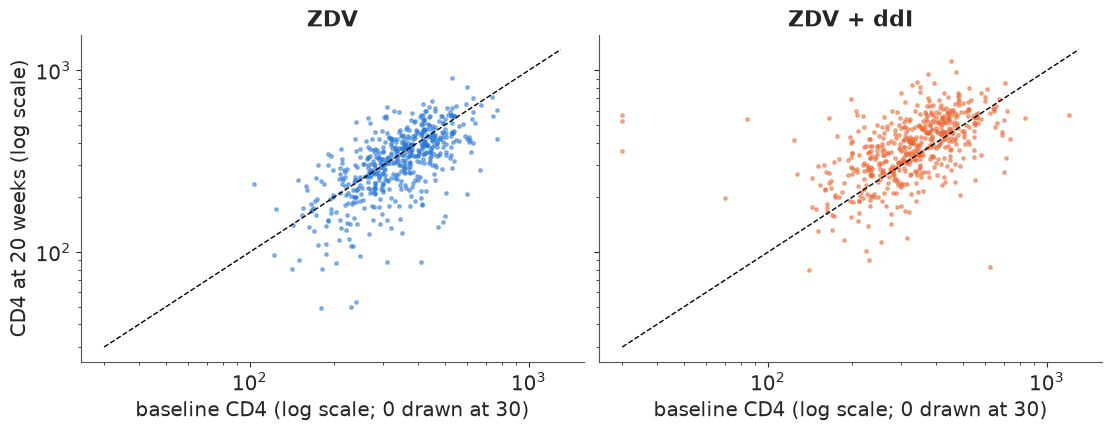

In [3]:
ARMS = ["ZDV", "ZDV + ddI"]
BLUE, ORANGE, AQUA, GREY, PURPLE = "#2a78d6", "#eb6834", "#1baf7a", "#8a8a86", "#8a5cc2"

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), sharex=True, sharey=True)
for arm, ax in enumerate(axes):
    sub = trial[trial.trt == arm]
    ax.scatter(sub.cd40.clip(lower=30), sub.cd420, s=6, alpha=0.5, color=[BLUE, ORANGE][arm])
    ax.plot([30, 1300], [30, 1300], color="k", lw=1, ls="--")
    ax.set(xscale="log", yscale="log", title=ARMS[arm], xlabel="baseline CD4 (log scale; 0 drawn at 30)")
axes[0].set_ylabel("CD4 at 20 weeks (log scale)");

In [4]:
print(trial.loc[trial.cd40 < 100, ["trt", "cd40", "cd420", "cd80", "symptom", "str2"]])

        trt  cd40  cd420  cd80  symptom  str2
pidnum                                       
30134     1     0    359   468        0     1
30137     1     0    523  1087        0     1
50608     1    84    541   706        0     1
140744    1     0    566   998        0     0
260722    1    70    197   314        0     1


### Solution

On log-log axes the clouds are straight, and their vertical spread is about the same at 150
and at 600 cells: effects are **multiplicative**, so we model $\log$ CD4. On the raw scale the
spread grows with the level and a regression would need a variance model on top.

Three patients have a baseline CD4 of **exactly 0**, all three in the ddI arm, with 20-week
counts of 360-570. Entry required 200-500 cells, and a fall to zero followed by a recovery
to 500 within 20 weeks is not biology: these are coding errors (most likely a missing value
stored as 0). We drop them - three of 1054 - and say so. The next-lowest baselines (70 and 84
cells) are unusual but possible: the eligibility count and the baseline count were separate
measurements (baseline counts go up to 1199, far outside 200-500).

In [5]:
df = trial[trial.cd40 > 0].reset_index(drop=True)
N = len(df)
y = np.log(df.cd420.to_numpy(float))
t = df.trt.to_numpy(int)
log_cd4 = np.log(df.cd40.to_numpy(float))
lx = log_cd4 - log_cd4.mean()                     # centred log baseline CD4
change = y - log_cd4                              # log ratio 20 weeks / baseline


def std(v):
    v = np.asarray(v, float)
    return (v - v.mean()) / v.std()


# other baseline covariates, standardised (binary ones too, so all priors share one scale)
Z = pd.DataFrame({
    "log_cd8": std(np.log(df.cd80)), "age": std(df.age), "weight": std(df.wtkg),
    "prior_art": std(df.str2), "symptom": std(df.symptom), "karnof_100": std(df.karnof == 100),
    "male": std(df.gender), "nonwhite": std(df.race), "drugs": std(df.drugs),
    "haemophilia": std(df.hemo), "msm": std(df.homo),
})
Zs = Z.to_numpy()
print(f"{N} patients: {np.sum(t == 0)} ZDV, {np.sum(t == 1)} ZDV + ddI")

pd.DataFrame({
    "mean": pd.Series(change).groupby(t).mean(),
    "sd": pd.Series(change).groupby(t).std(),
    "skewness": pd.Series(change).groupby(t).apply(stats.skew),
    "excess kurtosis": pd.Series(change).groupby(t).apply(stats.kurtosis),
    "share falling > 25%": pd.Series(change < np.log(0.75)).groupby(t).mean(),
}, ).set_axis(ARMS).round(3)

1051 patients: 532 ZDV, 519 ZDV + ddI


,mean,sd,skewness,excess kurtosis,share falling > 25%
ZDV,-0.082,0.340,-0.888,2.280,0.197
ZDV + ddI,0.123,0.369,-0.222,3.096,0.102


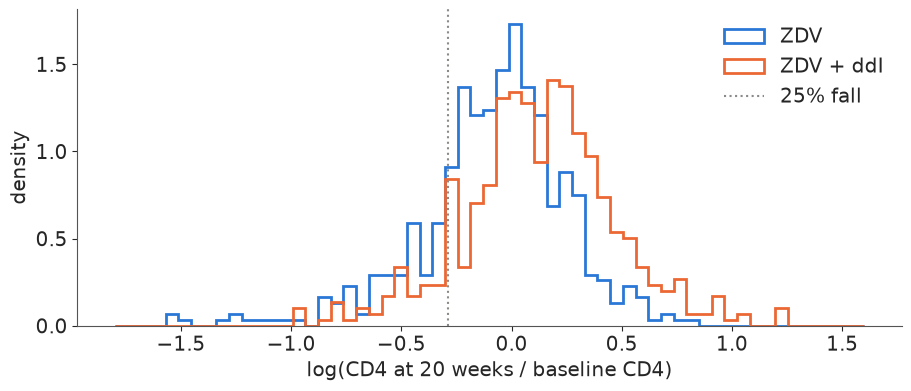

In [6]:
fig, ax = plt.subplots(figsize=(9, 3.8))
bins = np.linspace(-1.8, 1.6, 60)
for arm in [0, 1]:
    ax.hist(change[t == arm], bins=bins, histtype="step", lw=2, density=True, color=[BLUE, ORANGE][arm], label=ARMS[arm])
ax.axvline(np.log(0.75), color=GREY, ls=":", label="25% fall")
ax.set(xlabel="log(CD4 at 20 weeks / baseline CD4)", ylabel="density")
ax.legend();

On ZDV alone the typical patient's CD4 falls (mean log ratio -0.08, about -8%); with ddI
added it rises by about 13%. The spreads are similar (sd 0.34-0.37 on the log scale), but the
**shape** is not normal: both arms have a long left tail - patients whose CD4 count
collapsed - and excess kurtosis of 2-3. The ZDV arm is clearly left-skewed (-0.9); in the ddI
arm the skew is weaker (-0.2) because its left tail is thinner: one patient in five on ZDV
lost more than a quarter of their CD4 cells, one in ten on ZDV + ddI. A regression with
normal errors will have to squeeze these tails into a symmetric bell - and a treatment that
changes the *shape* of the outcome distribution, not just its centre, is the first hint that
a single regression line is not the whole story.

## Task 1 · One regression for everybody

**Deliver**
1. A linear regression of log CD4 at 20 weeks on log baseline CD4, treatment and the other
   baseline covariates, with priors you can defend on the log scale, and clean diagnostics.
2. The treatment effect as a **percentage** change in CD4, with a 94% interval.
3. A posterior predictive check, per arm, that shows what this model gets wrong - pick
   the statistic that matters for a clinic worried about patients who deteriorate.

### Solution

Log scale: the intercept is the log CD4 of an average patient on ZDV, about $\log 340 = 5.8$,
so `Normal(5.8, 1)` is generous. The slope on log baseline CD4 is an elasticity: 1 means
"20-week count proportional to baseline", below 1 means regression to the mean; `Normal(0.7,
0.5)` covers both. A treatment effect of ±0.5 on the log scale is ±65%, far beyond anything
a nucleoside drug does in 20 weeks: `Normal(0, 0.5)`. The other covariates are standardised
and get `Normal(0, 0.2)`: none of them should move CD4 by more than about 20% per sd.

In [7]:
def fit(model, **kw):
    """One place for sampler settings; every fit reports its time and divergences."""
    kw.setdefault("target_accept", 0.9)
    t0 = time.time()
    with model:
        idata = pm.sample(random_seed=RANDOM_SEED, progressbar=False, **kw)
    div = idata.sample_stats["diverging"].sum("draw").to_numpy()
    print(f"  {time.time() - t0:4.0f} s, divergences per chain = {div}, tuning = {idata.posterior.attrs.get('tuning_steps')}")
    return idata


coords = {"covariate": list(Z.columns), "patient": np.arange(N)}


def single_regression(errors="normal", interactions=None):
    with pm.Model(coords=coords) as m:
        a = pm.Normal("a", 5.8, 1.0)
        b = pm.Normal("b", 0.7, 0.5)
        c = pm.Normal("c", 0.0, 0.5)
        g = pm.Normal("g", 0.0, 0.2, dims="covariate")
        cate = c
        if interactions:  # treatment x standardised log baseline CD4 ("cd4"), plus the others ("all")
            c_cd4 = pm.Normal("c_cd4", 0.0, 0.2)
            cate = c + c_cd4 * lx / lx.std()
            if interactions == "all":
                cate = cate + Zs @ pm.Normal("c_z", 0.0, 0.2, dims="covariate")
            cate = pm.Deterministic("cate", cate, dims="patient")
        mu = a + b * lx + cate * t + Zs @ g
        sigma = pm.HalfNormal("sigma", 1.0)
        if errors == "normal":
            pm.Normal("y", mu, sigma, observed=y, dims="patient")
        else:
            nu = pm.Gamma("nu", 2.0, 0.1)
            pm.StudentT("y", nu=nu, mu=mu, sigma=sigma, observed=y, dims="patient")
    return m


single = single_regression()
idata_single = fit(single)
with single:
    pm.sample_posterior_predictive(idata_single, extend_inferencedata=True, random_seed=RANDOM_SEED, progressbar=False)
az.summary(idata_single, var_names=["a", "b", "c", "sigma"], ci_kind="hdi", ci_prob=0.94, round_to=3)

     2 s, divergences per chain = [0 0 0 0], tuning = 400


,mean,sd,hdi94_lb,hdi94_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
a,5.725,0.014,5.699,5.751,2669.157,2957.222,1.000,0.0,0.000
b,0.725,0.031,0.668,0.784,5222.831,3152.806,1.000,0.0,0.001
c,0.201,0.020,0.164,0.239,2681.924,2969.150,1.001,0.0,0.000
sigma,0.332,0.007,0.320,0.346,7158.259,3224.012,1.001,0.0,0.000


In [8]:
eff = 100 * (np.exp(idata_single.posterior["c"].to_numpy().ravel()) - 1)
print(f"ddI effect: {eff.mean():+.1f}% CD4 at 20 weeks, 94% interval {np.quantile(eff, [0.03, 0.97]).round(1)}")
diag = az.summary(idata_single, var_names=["a", "b", "c", "g", "sigma"])
print(f"worst r_hat: {diag.r_hat.max():.3f}, smallest bulk ESS: {diag.ess_bulk.min():.0f}")

ddI effect: +22.2% CD4 at 20 weeks, 94% interval [17.5 26.9]
worst r_hat: 1.003, smallest bulk ESS: 1921


In [9]:
assert h.check("task1", effect=idata_single.posterior["c"].mean(), sigma=idata_single.posterior["sigma"].mean())

- PASS `effect` = 0.2005 is consistent with the reference solution.
- PASS `sigma` = 0.3324 is consistent with the reference solution.

The sampler is happy, and the average effect is clear: adding ddI raises the 20-week CD4
count by about 22% (94% interval roughly 18-27%). Now the check. The clinic's worry is the
patients who deteriorate, so we ask the model for the share of patients per arm whose CD4
falls by more than 25%, and for the skewness of the change - two statistics the normal
errors are not free to fit.

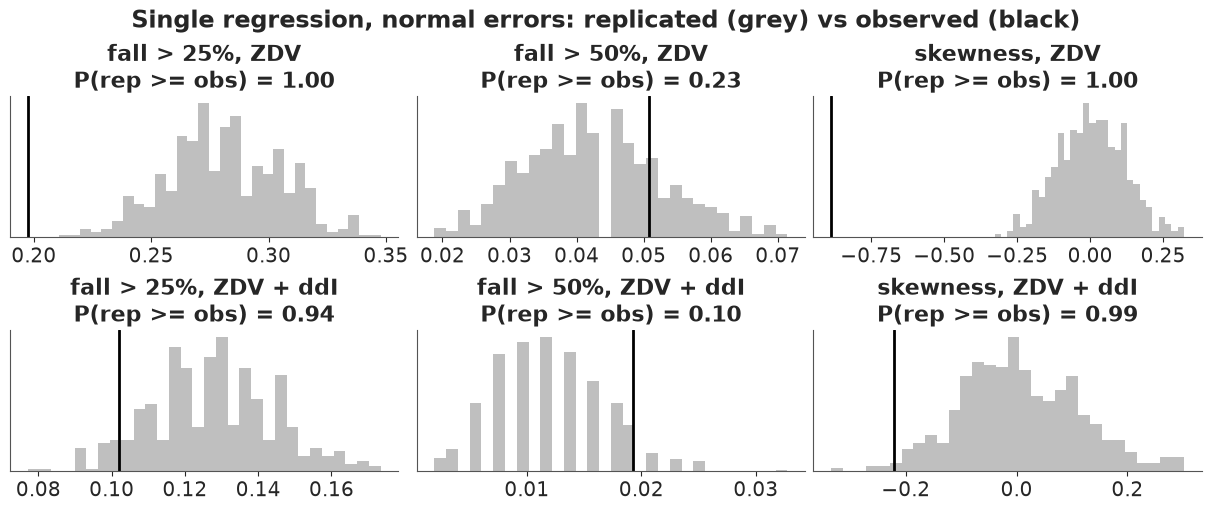

In [10]:
def ppc_stats(y_rep):
    """Tail shares and skewness of log(CD4 20 wk / baseline), per arm, for (draws, N) replicates."""
    ch = y_rep - log_cd4
    out = {}
    for arm in [0, 1]:
        out[f"fall > 25%, {ARMS[arm]}"] = (ch[:, t == arm] < np.log(0.75)).mean(1)
        out[f"fall > 50%, {ARMS[arm]}"] = (ch[:, t == arm] < np.log(0.5)).mean(1)
        out[f"skewness, {ARMS[arm]}"] = stats.skew(ch[:, t == arm], axis=1)
    return pd.DataFrame(out)


def plot_ppc(rep_stats, title):
    obs = ppc_stats(y[None, :]).iloc[0]
    fig, axes = plt.subplots(2, 3, figsize=(12, 5))
    for ax, col in zip(axes.ravel(), rep_stats.columns):
        ax.hist(rep_stats[col], bins=30, color="0.75")
        ax.axvline(obs[col], color="k", lw=2)
        p = (rep_stats[col] >= obs[col]).mean()
        ax.set(title=f"{col}\nP(rep >= obs) = {p:.2f}", yticks=[])
    fig.suptitle(title)


y_rep_single = az.extract(idata_single, group="posterior_predictive", var_names="y", num_samples=500,
                          random_seed=RANDOM_SEED).transpose("sample", ...).to_numpy()
plot_ppc(ppc_stats(y_rep_single), "Single regression, normal errors: replicated (grey) vs observed (black)");

The model fails, and not quite in the direction one might guess. Every replicated dataset has
skewness near zero while the ZDV arm sits at -0.9. To reach the long left tail, the normal
has to inflate its sd, so it predicts **too many moderate falls**: about 28% of ZDV patients
losing a quarter of their CD4 against 20% observed (no replicate is that low). The extreme
falls (more than 50%) happen to come out about right. A symmetric bell fitted to a
left-skewed outcome is too wide in the middle and has the wrong shape in the tail; the average
effect may survive this, but statements about *which patients* fare badly will not.

## Task 2 · A Dirichlet-process mixture of regressions

Suppose the patients fall into hidden subgroups, each with its **own regression**: its own
intercept, slope on baseline CD4, treatment effect and residual spread (the other covariates
may keep shared coefficients). Nobody knows how many subgroups there are.

**Deliver**
1. That model, with a truncated Dirichlet-process (stick-breaking) prior on the subgroup
   weights and the subgroup memberships marginalised. Show what your prior on the
   concentration implies for the number of subgroups among these patients, and check that the
   truncation does not bite.
2. Evidence that the sampler worked. Decide which quantities it is meaningful to diagnose.
3. Did it fix what Task 1 got wrong? The same PPC, and a LOO comparison with Task 1 **and**
   with a single regression that merely has heavier tails. How much of the improvement
   needs subgroups?
4. The average treatment effect, and how different the subgroups' treatment effects are.

### Solution

First the prior on the number of occupied subgroups. As E26 showed, the concentration
$\alpha$ sets it, and it grows with $n$. For 1051 patients:

In [11]:
def prior_K(alpha, n, rng):
    """Occupied clusters for n draws from a DP (Chinese restaurant), vectorised over alpha."""
    K = np.zeros_like(alpha)
    for i in range(n):
        K += rng.random(alpha.shape) < np.where(i == 0, 1.0, alpha / (alpha + i))
    return K


for label, a_draws in [("alpha ~ Gamma(2, 2)", rng.gamma(2.0, 0.5, 4000)),
                       ("alpha ~ Gamma(2, 1)", rng.gamma(2.0, 1.0, 4000))]:
    q = np.quantile(prior_K(a_draws, N, rng), [0.05, 0.5, 0.95])
    print(f"{label}: prior occupied subgroups, median {q[1]:.0f}, 90% interval {q[0]:.0f}-{q[2]:.0f}")

alpha ~ Gamma(2, 2): prior occupied subgroups, median 6, 90% interval 2-16
alpha ~ Gamma(2, 1): prior occupied subgroups, median 11, 90% interval 3-28


`Gamma(2, 2)` (mean 1) allows anything from a couple of subgroups to a dozen or so, which
is humble enough; the popular `Gamma(2, 1)` would push the prior median towards 13, most of them
tiny. Truncation at $T = 12$ components leaves an expected stick remainder of
$(\alpha/(1+\alpha))^{11}$, about $5 \times 10^{-4}$ at $\alpha = 1$; we check it afterwards.

The subgroup-specific priors are Task 1's, with one change: residual sds get
`InverseGamma(3, 0.5)` (median 0.19, 90% interval 0.08-0.47) instead of a half-normal, so no
component can shrink onto a few patients with a near-zero spread (E26). `pm.NormalMixture`
accepts a `(patients, components)` matrix of means, which marginalises the memberships.

In [12]:
print("InverseGamma(3, 0.5) quantiles:", stats.invgamma(3.0, scale=0.5).ppf([0.05, 0.5, 0.95]).round(2))
T = 12


def dp_regression(T=T):
    with pm.Model(coords=coords | {"component": np.arange(T)}) as m:
        alpha = pm.Gamma("alpha", 2.0, 2.0)
        w = pm.StickBreakingWeights("w", alpha=alpha, K=T - 1, dims="component")
        a = pm.Normal("a", 5.8, 1.0, dims="component")
        b = pm.Normal("b", 0.7, 0.5, dims="component")
        c = pm.Normal("c", 0.0, 0.5, dims="component")
        sigma = pm.InverseGamma("sigma", 3.0, 0.5, dims="component")
        g = pm.Normal("g", 0.0, 0.2, dims="covariate")
        mu = a + b * lx[:, None] + c * t[:, None] + (Zs @ g)[:, None]
        ate = pm.Deterministic("ate", (w * c).sum())
        pm.Deterministic("effect_sd", pt.sqrt((w * (c - ate) ** 2).sum()))  # spread of subgroup effects
        pm.NormalMixture("y", w=w, mu=mu, sigma=sigma, observed=y, dims="patient")
    return m


dp = dp_regression()
idata_dp = fit(dp)
az.summary(idata_dp, var_names=["w", "c", "sigma"], round_to=2).sort_values("r_hat", ascending=False).head(8)

InverseGamma(3, 0.5) quantiles: [0.08 0.19 0.61]


    21 s, divergences per chain = [0 0 8 0], tuning = 400


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
sigma[1],0.24,0.09,0.13,0.43,47.50,74.50,1.07,0.01,0.01
c[0],0.20,0.15,0.05,0.44,58.74,104.41,1.06,0.02,0.02
sigma[0],0.25,0.09,0.15,0.43,80.33,66.25,1.06,0.01,0.01
w[0],0.39,0.22,0.05,0.74,107.25,181.18,1.05,0.02,0.01
sigma[2],0.28,0.12,0.12,0.49,125.44,282.28,1.05,0.01,0.01
w[1],0.31,0.21,0.04,0.69,72.98,130.96,1.05,0.03,0.01
c[1],0.20,0.19,-0.02,0.48,88.27,153.67,1.04,0.03,0.03
c[2],0.25,0.25,-0.13,0.63,242.04,439.57,1.02,0.01,0.01


The component table is the wrong place to look (E26): component labels are not identified,
so $\hat R$ of "$c_3$" measures whether the chains agree on what to *call* each subgroup. Here
the worst are only mildly off ($\hat R$ up to about 1.07), but bulk ESS of 50-130 for the
leading weights and sds says the chains do trade labels. The quantities we will use are label-free - the average effect, the spread of
subgroup effects, $\alpha$, the log density - and those are what we diagnose, along with the
last stick:

In [13]:
def label_free(idata, names):
    ds = xr.Dataset({n: idata.posterior[n] for n in names} | {"logp": idata.sample_stats["logp"]})
    return pd.DataFrame({"r_hat": az.rhat(ds).to_pandas(), "ess_bulk": az.ess(ds).to_pandas()}).round(3)


print(label_free(idata_dp, ["ate", "effect_sd", "alpha"]))
w_last = idata_dp.posterior["w"].isel(component=-1)
print(f"last stick w_T: mean {float(w_last.mean()):.1e}, 99th percentile {float(w_last.quantile(0.99)):.1e}")
w_sorted = np.sort(idata_dp.posterior["w"].to_numpy(), axis=-1)[..., ::-1]
print("posterior mean of the sorted weights:", w_sorted.mean((0, 1))[:6].round(3))

           r_hat  ess_bulk
ate        0.999  3268.079
effect_sd  1.006   370.075
alpha      1.008   271.447
logp       1.012   386.730
last stick w_T: mean 9.3e-04, 99th percentile 1.9e-02
posterior mean of the sorted weights: [0.555 0.239 0.121 0.051 0.019 0.008]


The label-free quantities mix well, and the last of the twelve sticks carries a negligible
share even at its 99th percentile. Three components carry about 90% of the weight on average.
(The fit reports a handful of divergences in one chain, well under 1% of the draws: worth
noting, and the label-free checks above are the reason not to worry more about it.)
What are they? Sorting components by weight *within each draw* is a crude relabelling, but
good enough to read the posterior:

In [14]:
post = az.extract(idata_dp, var_names=["w", "a", "b", "c", "sigma"], num_samples=1000, random_seed=RANDOM_SEED)
arr = {v: post[v].transpose("sample", ...).to_numpy() for v in ["w", "a", "b", "c", "sigma"]}
order = np.argsort(-arr["w"], axis=1)
table = {}
for v, x in arr.items():
    s = np.take_along_axis(x, order, axis=1)[:, :3]
    table[v] = [f"{np.median(s[:, k]):.2f} ({np.quantile(s[:, k], 0.05):.2f}, {np.quantile(s[:, k], 0.95):.2f})" for k in range(3)]
pd.DataFrame(table, index=["largest", "2nd", "3rd"])

,w,a,b,c,sigma
largest,"0.55 (0.37, 0.77)","5.79 (5.69, 5.87)","0.76 (0.58, 0.96)","0.16 (0.09, 0.22)","0.22 (0.18, 0.28)"
2nd,"0.24 (0.10, 0.38)","5.70 (5.29, 5.92)","0.71 (0.30, 1.15)","0.21 (0.04, 0.45)","0.26 (0.14, 0.46)"
3rd,"0.11 (0.04, 0.23)","5.65 (5.08, 6.03)","0.65 (0.05, 1.26)","0.27 (-0.07, 0.65)","0.28 (0.12, 0.51)"


The largest subgroup, about 55% of patients, is a well-behaved majority: residual sd 0.22 and
a treatment effect of +0.16 on the log scale. The smaller ones have lower intercepts, wider
spreads and somewhat larger effects, all with wide intervals - they collect the patients whose
counts fall or bounce around. Now the PPC and LOO, including a Student-t regression to separate
"subgroups" from "just heavier tails":

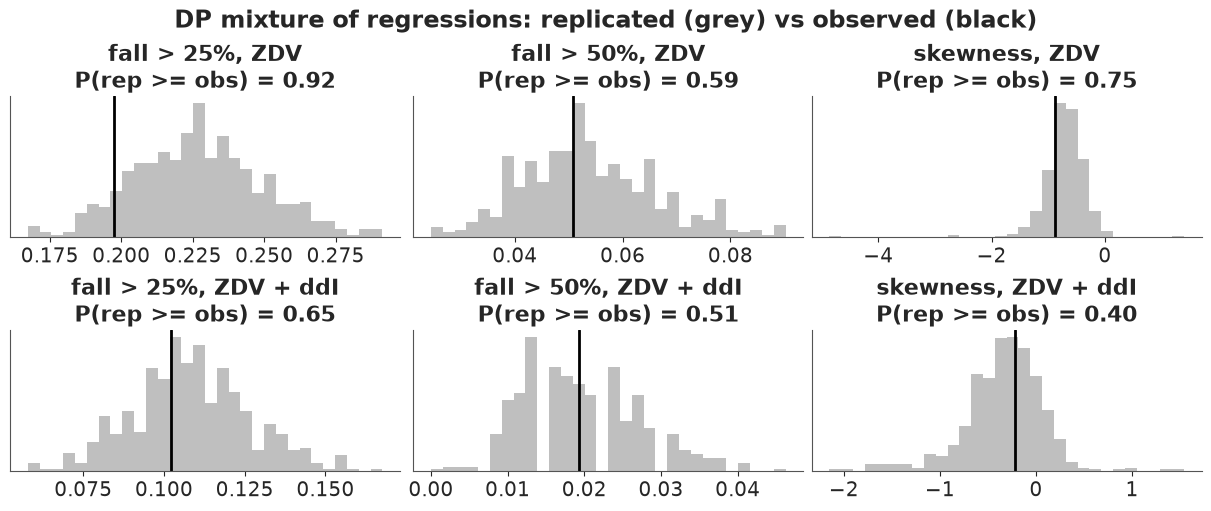

In [15]:
idata_dp_thin = idata_dp.isel(draw=slice(None, None, 8))
with dp:
    ppc_dp = pm.sample_posterior_predictive(idata_dp_thin, random_seed=RANDOM_SEED, progressbar=False)
y_rep_dp = ppc_dp.posterior_predictive["y"].stack(sample=("chain", "draw")).transpose("sample", ...).to_numpy()
plot_ppc(ppc_stats(y_rep_dp), "DP mixture of regressions: replicated (grey) vs observed (black)");

In [16]:
def loo_of(model, idata):
    """PSIS-LOO, keeping only what az.compare needs (memory: see AUTHORING.md)."""
    with model:
        pm.compute_log_likelihood(idata, progressbar=False)
    loo = az.loo(idata, pointwise=True)
    loo.log_weights = None
    del idata["log_likelihood"]
    return loo


student = single_regression(errors="student")
idata_student = fit(student)
print(az.summary(idata_student, var_names=["c", "nu", "sigma"], round_to=3))
loos = {"single, normal": loo_of(single, idata_single),
        "single, Student-t": loo_of(student, idata_student),
        "DP mixture": loo_of(dp, idata_dp)}
az.compare(loos, round_to=1)

     1 s, divergences per chain = [0 0 0 0], tuning = 400
        mean     sd  eti89_lb  eti89_ub  ess_bulk  ess_tail  r_hat  mcse_mean  \
c      0.177  0.019     0.148     0.207  2722.440  2776.440  1.001      0.000   
nu     4.869  0.771     3.803     6.179  2515.359  2578.691  1.002      0.016   
sigma  0.255  0.010     0.239     0.271  2470.000  2532.820  1.002      0.000   

       mcse_sd  
c        0.000  
nu       0.012  
sigma    0.000  


,rank,elpd_diff,dse,p_worse,diag_diff,diag_elpd,p,elpd,se,weight
DP mixture,0,0.0,0.0,NaN,,,35.9,-281.9,29.6,0.9
"single, Student-t",1,-13.8,5.6,1.0,,,16.4,-295.7,30.6,0.0
"single, normal",2,-59.3,15.9,1.0,,,17.0,-341.2,35.2,0.1


In [17]:
ate_dp = idata_dp.posterior["ate"]
print(f"ATE: {float(ate_dp.mean()):.3f} on the log scale = {100 * (np.exp(float(ate_dp.mean())) - 1):+.1f}% "
      f"(94% interval {np.round(100 * (np.exp(ate_dp.quantile([0.03, 0.97]).to_numpy()) - 1), 1)})")
es = idata_dp.posterior["effect_sd"]
print(f"sd of the treatment effect across subgroups: median {float(es.median()):.3f}, 90% interval {es.quantile([0.05, 0.95]).to_numpy().round(3)}")
elpd_gain = loos["DP mixture"].elpd - loos["single, normal"].elpd
print(f"elpd gain of the mixture over Task 1: {elpd_gain:.1f}")

ATE: 0.190 on the log scale = +20.9% (94% interval [16.4 25.7])
sd of the treatment effect across subgroups: median 0.127, 90% interval [0.062 0.231]
elpd gain of the mixture over Task 1: 59.3


In [18]:
assert h.check("task2", ate=ate_dp.mean(), elpd_gain=elpd_gain)

- PASS `ate` = 0.1898 is consistent with the reference solution.
- PASS `elpd_gain` = 59.34 is consistent with the reference solution.

**What the mixture fixed.** The replicated skewness and tail shares now cover the observed
values, and LOO prefers the mixture to the normal regression by a wide margin. But most of
that margin is available without any subgroups: the Student-t regression ($\nu \approx 5$)
recovers the larger part of it, and the mixture's remaining advantage comes from the one
thing a t cannot do - an *asymmetric* tail. So far the "subgroups" are a way of drawing a
skewed, heavy-tailed error distribution, exactly as in E26 a component was "a kernel, not a
population".

**The treatment effect.** The average effect is close to Task 1's (about +21%). The spread
of the subgroup-specific effects is clearly away from zero (median 0.13 on the log scale):
taken at face value, the subgroups respond differently, the small volatile ones more than the
majority. But no subgroup of any size has an effect near zero - the majority's is +0.16 (90%
interval 0.09-0.22) - so there is no "non-responder" subgroup in this model.

## Task 3 · The colleague's responder list

The statistician on the team took *your* Task 2 posterior and computed, for every patient
$i$, "their own treatment effect":

$$\widehat{\text{effect}}_i = \sum_k P(\text{patient } i \in \text{subgroup } k \mid \text{data})\; c_k,$$

averaged over posterior draws. The spread across patients is real, she says: rank them, give
ddI to the top half (the "responders"), and spare the bottom half.

**Deliver**
1. Her numbers, for every patient in both arms.
2. What is wrong with using them to decide who gets ddI. There are two separate problems;
   show each with a number or a plot, not only an argument.
3. What your Task 2 model predicts as the treatment effect for a **new** patient walking into
   the clinic, as a function of their baseline covariates. Explain the result.

### Solution

Her probabilities are the posterior membership ("responsibility") of each patient, draw by
draw: $P(z_i = k \mid y_i, \theta) \propto w_k\, \text{Normal}(y_i \mid \mu_{ik}, \sigma_k)$.
The sum over $k$ makes her score label-free, so label switching is *not* the problem.

           score: 5%  median    95%  share flagged 'responder'  \
ZDV            0.164   0.173  0.294                      0.414   
ZDV + ddI      0.166   0.179  0.250                      0.588   

           corr(score, observed change)  
ZDV                              -0.738  
ZDV + ddI                         0.537  


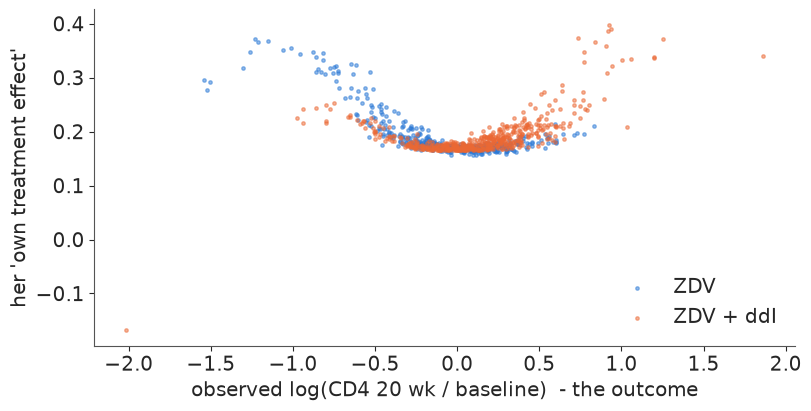

In [19]:
post = az.extract(idata_dp, var_names=["w", "a", "b", "c", "sigma", "g"], num_samples=500, random_seed=RANDOM_SEED)
W, A, B, C, S = (post[v].transpose("sample", ...).to_numpy() for v in ["w", "a", "b", "c", "sigma"])
G = post["g"].transpose("sample", ...).to_numpy()
MU = A[:, None, :] + B[:, None, :] * lx[None, :, None] + C[:, None, :] * t[None, :, None] + (G @ Zs.T)[:, :, None]
log_r = np.log(W)[:, None, :] + stats.norm.logpdf(y[None, :, None], MU, S[:, None, :])
resp = np.exp(log_r - log_r.max(-1, keepdims=True))
resp /= resp.sum(-1, keepdims=True)                               # (draws, patients, components)
score = (resp * C[:, None, :]).sum(-1).mean(0)                   # her "own treatment effect"
del MU, log_r, resp

corr = {arm: np.corrcoef(score[t == arm], change[t == arm])[0, 1] for arm in [0, 1]}
top = score > np.median(score)
print(pd.DataFrame({
    "score: 5%": pd.Series(score).groupby(t).quantile(0.05), "median": pd.Series(score).groupby(t).median(),
    "95%": pd.Series(score).groupby(t).quantile(0.95), "share flagged 'responder'": pd.Series(top).groupby(t).mean(),
    "corr(score, observed change)": pd.Series(corr),
}).set_axis(ARMS).round(3))

fig, ax = plt.subplots(figsize=(8, 4))
for arm in [0, 1]:
    ax.scatter(change[t == arm], score[t == arm], s=6, alpha=0.5, color=[BLUE, ORANGE][arm], label=ARMS[arm])
ax.set(xlabel="observed log(CD4 20 wk / baseline)  - the outcome", ylabel="her 'own treatment effect'")
ax.legend();

In [20]:
assert h.check("task3", corr_control=corr[0], corr_treated=corr[1])

- PASS `corr_control` = -0.7381 is consistent with the reference solution.
- PASS `corr_treated` = 0.5371 is consistent with the reference solution.

**Problem 1: the score is computed from the outcome.** The membership probabilities
condition on $y_i$, the CD4 count *after* 20 weeks of treatment. The plot shows what that
does: the score is a U-shaped function of the outcome. Anybody whose CD4 moved a lot - up or
down - is assigned to the small high-spread subgroups, whose treatment coefficients happen to
be larger, and becomes a "responder". Which extreme dominates differs by arm (falls on ZDV,
rises on ZDV + ddI), hence correlations of **opposite sign**: on ZDV, *doing badly without
ddI* makes you a responder. Her ranking re-sorts patients by how their CD4 moved, i.e. by
noise and disease course, and it flags 41% of the ZDV patients - who never received ddI - as
responders (59% in the ddI arm).

**Problem 2: the clinic cannot compute it.** A new patient has no 20-week CD4 count. What the
model says about a new patient uses only the prior membership probabilities, which in Task 2
are the global weights $w_k$ - the same for everybody:

In [21]:
cate_new = (W * C).sum(-1)                                        # identical for every new patient
print(f"Task 2 model, effect for ANY new patient: {cate_new.mean():.3f} (log scale), "
      f"94% interval {np.quantile(cate_new, [0.03, 0.97]).round(3)} - whatever their covariates")

Task 2 model, effect for ANY new patient: 0.189 (log scale), 94% interval [0.152 0.229] - whatever their covariates


In a mixture whose weights ignore the covariates, $E[y \mid x, \text{ddI}] - E[y \mid x,
\text{ZDV}] = \sum_k w_k c_k$ (the subgroup-specific slopes cancel in the difference, and the
shared coefficients do too). The model *can* say that effects vary between subgroups, but it
has no way to say *who is in which subgroup* before treatment: it cannot target anybody. For a
treatment rule, subgroup membership has to be predictable from what the clinic knows at
baseline. That is Task 4.

For the clinic, in one paragraph: *the "responder" list sorts patients by how their CD4
count happened to move, which is the outcome itself; it would flag ZDV-only patients as
ddI responders too, and it cannot be computed for a new patient. It is not evidence of a
subgroup that does not benefit.*

## Task 4 · Let the baseline profile choose the subgroup

**Deliver**
1. A mixture of regressions whose subgroup probabilities depend on **baseline** covariates
   (and on nothing measured after randomisation). Say which covariates, and why.
2. Evidence that the quantities you will base decisions on have converged - for *every*
   patient, not just on average - and that your conclusions do not depend on which chain you
   happen to look at.
3. A plot of each patient's conditional average treatment effect (CATE) against baseline CD4,
   with uncertainty, next to what Task 2 said.
4. A LOO comparison with Task 2. What does it tell you - and what can LOO not see here?

### Solution

**Logistic stick-breaking** (Ren et al. 2011; Rigon & Durante 2021) makes each stick's
breaking fraction a logistic regression on the baseline profile $x_i$:

$$v_{ik} = \text{logit}^{-1}(\gamma_{0k} + x_i^\top \gamma_k), \qquad
w_{ik} = v_{ik} \prod_{\ell < k} (1 - v_{i\ell}), \qquad k = 1, \dots, T-1,$$

and the last component takes the rest. With $\gamma_k = 0$ it is an ordinary stick-breaking
prior with $v_k \sim \text{logit}^{-1}(\text{Normal}(0, 1.5))$ - roughly a DP with
$\alpha \approx 1$. The patient's CATE is then $\sum_k w_{ik} c_k$, and it varies with $x_i$.
Six components are plenty (Task 2 used three or four), and $\gamma$ gets `Normal(0, 1)` on
standardised covariates: one sd of a covariate can move a stick's log-odds by about 1.

**Which covariates?** Only baseline ones - a subgroup that is defined by something measured
after randomisation cannot be used to choose a treatment (Task 3). Among those we gate on **log
baseline CD4** alone. It is the pre-specified effect modifier in HIV trials of this era
(disease stage), and a gate is a flexible regression: with a dozen covariates and about a
thousand patients it has many ways to route the few patients in thin corners of covariate
space, and in our development runs a gate on every covariate mixed erratically (per-patient
$\hat R$ from 1.01 to 1.2 depending on the seed). The interaction regression in Task 5 is the
check that we have not missed a modifier.

In a logistic stick-breaking model the last component is a real component, not a truncation
remainder, so the check of $T$ is different from Task 2: count, per draw, the components that
carry more than 5% of the weight for *any* patient. If that is well below $T$, more components
would not change anything. We also run 2000 draws per chain: the per-patient CATEs are what
the clinic will use.

In [22]:
T_GATE = 6


def gated_regression(gate_cols, T=T_GATE):
    Xg = np.column_stack([lx / lx.std() if col == "log_cd4" else Z[col].to_numpy() for col in gate_cols])
    with pm.Model(coords=coords | {"component": np.arange(T), "stick": np.arange(T - 1), "gate": gate_cols}) as m:
        a = pm.Normal("a", 5.8, 1.0, dims="component")
        b = pm.Normal("b", 0.7, 0.5, dims="component")
        c = pm.Normal("c", 0.0, 0.5, dims="component")
        sigma = pm.InverseGamma("sigma", 3.0, 0.5, dims="component")
        g = pm.Normal("g", 0.0, 0.2, dims="covariate")
        mu = a + b * lx[:, None] + c * t[:, None] + (Zs @ g)[:, None]
        g0 = pm.Normal("g0", 0.0, 1.5, dims="stick")
        gam = pm.Normal("gamma", 0.0, 1.0, dims=("gate", "stick"))
        v = pm.math.sigmoid(g0 + Xg @ gam)                           # (patients, sticks)
        w = pt.concatenate([v, pt.ones((N, 1))], axis=1) * pt.concatenate([pt.ones((N, 1)), pt.cumprod(1 - v, axis=1)], axis=1)
        cate = pm.Deterministic("cate", (w * c).sum(-1), dims="patient")
        pm.Deterministic("ate", cate.mean())
        pm.Deterministic("n_used", (w.max(0) > 0.05).sum())          # label-free truncation check
        pm.NormalMixture("y", w=w, mu=mu, sigma=sigma, observed=y, dims="patient")
    return m


def cate_convergence(idata):
    r = az.rhat(idata, var_names=["cate"])["cate"].to_numpy()
    e = az.ess(idata, var_names=["cate"])["cate"].to_numpy()
    return pd.Series({"max r_hat": r.max().round(3), "share r_hat > 1.01": (r > 1.01).mean().round(2),
                      "min ess_bulk": int(e.min()), "median ess_bulk": int(np.median(e))})


gated = gated_regression(["log_cd4"])
idata_gated = fit(gated, tune=1000, draws=2000)
print(cate_convergence(idata_gated).to_string())
print(label_free(idata_gated, ["ate"]))
print("components carrying > 5% for some patient:",
      pd.Series(idata_gated.posterior["n_used"].to_numpy().ravel()).value_counts(normalize=True).sort_index().round(3).to_dict())

    38 s, divergences per chain = [1 4 2 5], tuning = 1000


max r_hat                1.026
share r_hat > 1.01       0.110
min ess_bulk           346.000
median ess_bulk       3905.000
      r_hat  ess_bulk
ate   1.001  7844.454
logp  1.027   180.641
components carrying > 5% for some patient: {2.0: 0.052, 3.0: 0.368, 4.0: 0.353, 5.0: 0.184, 6.0: 0.042}


In [23]:
CD4_BANDS = [0, 200, 265, 340, 424, 550, 1300]
band = pd.cut(df.cd40, CD4_BANDS)
cate_chain = idata_gated.posterior["cate"].mean("draw").to_numpy()        # (chain, patient)
rhat_cate = az.rhat(idata_gated, var_names=["cate"])["cate"].to_numpy()
per_chain = pd.DataFrame({f"chain {k}": pd.Series(cate_chain[k]).groupby(band.to_numpy()).mean() for k in range(cate_chain.shape[0])})
per_chain["patients"] = band.value_counts().sort_index().to_numpy()
per_chain["max r_hat"] = pd.Series(rhat_cate).groupby(band.to_numpy()).max()
per_chain.round(3)

,chain 0,chain 1,chain 2,chain 3,patients,max r_hat
"(0, 200]",0.306,0.297,0.300,0.291,90,1.013
"(200, 265]",0.247,0.242,0.243,0.240,174,1.011
"(265, 340]",0.207,0.205,0.205,0.205,263,1.003
"(340, 424]",0.180,0.180,0.180,0.181,261,1.001
"(424, 550]",0.160,0.163,0.162,0.164,208,1.004
"(550, 1300]",0.135,0.142,0.139,0.144,55,1.026


A dozen divergences out of 8000 draws is small but not zero - one more reason to look
closely.
Read the tables together. The per-patient $\hat R$ values are the strict test, and they are
not perfect: across our builds the largest has ranged from about 1.01 to 1.09 (nutpie runs are
not bit-reproducible), and the log density's $\hat R$ is a little above 1.01 too, with the
worst patients at the extremes of baseline CD4, where few patients inform the gate. The chains
are not perfectly interchangeable. The per-chain table shows what that means in practice: each
chain's average CATE per CD4 band agrees with the others to within about 0.015, the largest
differences sit in the outer bands, and the average effect mixes perfectly. In most draws
three to five of the six components carry more than 5% of the weight for some patient, all six
only rarely, so more components would change little. The chains differ in how they draw the
curve at the edges, not in the conclusion - which Task 5 checks once more on the decision
itself. (Running longer, or more chains, is the honest remedy if a decision hinges on a
patient at the edge.)

The CATE against baseline CD4:

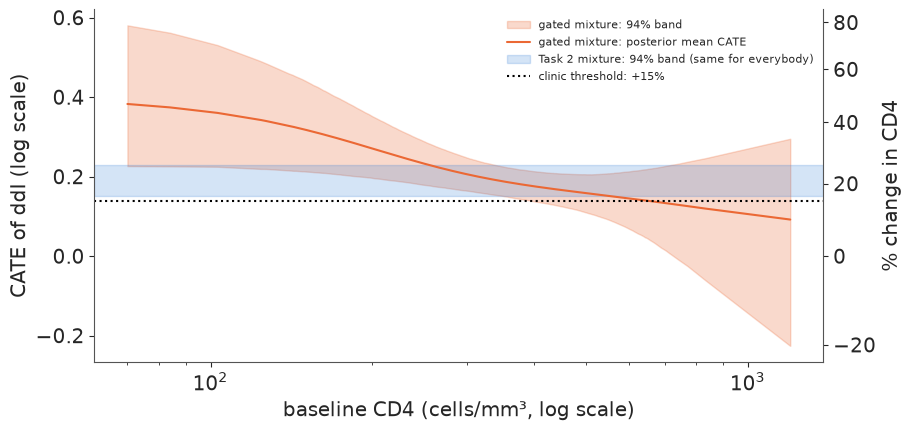

In [24]:
cate_draws = idata_gated.posterior["cate"].stack(sample=("chain", "draw")).transpose("sample", ...).to_numpy()
cate_mean = cate_draws.mean(0)
order_cd4 = np.argsort(df.cd40.to_numpy())
lo, hi = np.quantile(cate_draws, [0.03, 0.97], axis=0)

fig, ax = plt.subplots(figsize=(9, 4.2))
xs = df.cd40.to_numpy()[order_cd4]
ax.fill_between(xs, lo[order_cd4], hi[order_cd4], color=ORANGE, alpha=0.25, label="gated mixture: 94% band")
ax.plot(xs, cate_mean[order_cd4], color=ORANGE, label="gated mixture: posterior mean CATE")
ax.axhspan(*np.quantile(cate_new, [0.03, 0.97]), color=BLUE, alpha=0.2, label="Task 2 mixture: 94% band (same for everybody)")
ax.axhline(np.log(1.15), color="k", ls=":", label="clinic threshold: +15%")
ax.set(xscale="log", xlabel="baseline CD4 (cells/mm³, log scale)", ylabel="CATE of ddI (log scale)")
secax = ax.secondary_yaxis("right", functions=(lambda v: 100 * (np.exp(v) - 1), lambda p: np.log1p(p / 100)))
secax.set_ylabel("% change in CD4")
ax.legend(fontsize=8);

In [25]:
q1, q3 = np.quantile(df.cd40, [0.25, 0.75])
low, high = df.cd40.to_numpy() <= q1, df.cd40.to_numpy() >= q3
cate_low, cate_high = cate_draws[:, low].mean(1), cate_draws[:, high].mean(1)
print(f"mean CATE, baseline CD4 <= {q1:.0f}: {cate_low.mean():.3f}   >= {q3:.0f}: {cate_high.mean():.3f}   "
      f"P(low > high) = {(cate_low > cate_high).mean():.3f}")

mean CATE, baseline CD4 <= 265: 0.262   >= 424: 0.158   P(low > high) = 0.992


In [26]:
assert h.check("task4", cate_low=cate_low.mean(), cate_high=cate_high.mean())

- PASS `cate_low` = 0.2618 is consistent with the reference solution.
- PASS `cate_high` = 0.1577 is consistent with the reference solution.

In [27]:
loos["gated mixture (CD4)"] = loo_of(gated, idata_gated)
az.compare(loos, round_to=1)

,rank,elpd_diff,dse,p_worse,diag_diff,diag_elpd,p,elpd,se,weight
gated mixture (CD4),0,0.0,0.0,NaN,,,35.0,-274.3,29.6,0.9
DP mixture,1,-7.6,3.0,1.0,,,35.9,-281.9,29.6,0.0
"single, Student-t",2,-21.3,7.1,1.0,,,16.4,-295.7,30.6,0.0
"single, normal",3,-66.9,16.3,1.0,,,17.0,-341.2,35.2,0.1


**What the gated model says.** The relative benefit of ddI falls steadily with baseline CD4:
about +30% for patients in the lowest quartile of baseline CD4 against +17% in the highest, and
the posterior probability that the lowest quartile gains more is close to 1. Task 2 could only
draw a horizontal band.

**What LOO says: not much about that.** The gated model is ahead of the Task 2 mixture by
several elpd, a little over two standard errors of the difference - modest evidence that CD4-dependent
weights predict better, and most of it may come from routing the *prognosis* (who is likely to
fall), not the treatment effect. LOO scores how well each model predicts a patient's CD4
count, and a treatment effect that varies by ten percentage points is small next to a
residual spread of about 30%: two models can disagree completely about effect modification and
predict almost equally well. **Predictive accuracy is the wrong yardstick for effect
heterogeneity.** The evidence has to come from the posterior of the contrast itself (low vs
high CD4 above), from a model with a different structure agreeing (Task 5), and ideally from a
second trial.

## Task 5 · The clinic's rule

Recall the rule: *ddI is worth it for a patient if it raises their CD4 count at 20 weeks by
at least 15%, with probability at least 0.8.*

**Deliver**
1. For every patient, the probability that their expected gain exceeds 15% under your Task 4
   model, and the share of patients the rule would put on ddI. Who is left out? Does the
   answer depend on the chain?
2. The same from two plain regressions: one with a treatment × baseline CD4 interaction, one
   with treatment × every baseline covariate. Where do the three disagree, and why?
3. Your recommendation to the clinic in a few sentences, including what the analysis cannot
   tell them.

### Solution

"Expected gain" is the CATE on the log scale, i.e. the ratio of typical (geometric-mean)
CD4 counts with and without ddI, so the rule is $P(\text{CATE}_i > \log 1.15) \ge 0.8$.

In [28]:
THRESHOLD, CONFIDENCE = np.log(1.15), 0.8
p_mix = (cate_draws > THRESHOLD).mean(0)
p_chain = (idata_gated.posterior["cate"] > THRESHOLD).mean("draw").to_numpy()   # (chain, patient)
print("share treated, chain by chain:", ((p_chain >= CONFIDENCE).mean(1)).round(3))

p_int, fits_int = {}, {}
for kind in ["cd4", "all"]:
    m = single_regression(interactions=kind)
    fits_int[kind] = fit(m)
    draws = fits_int[kind].posterior["cate"].stack(sample=("chain", "draw")).transpose("sample", ...).to_numpy()
    p_int[kind] = (draws > THRESHOLD).mean(0)
print(az.summary(fits_int["all"], var_names=["c", "c_cd4", "c_z"], round_to=3).iloc[:, :4])
print(az.summary(fits_int["cd4"], var_names=["c", "c_cd4"], round_to=3).iloc[:, :4])

shares = {"gated mixture (CD4)": (p_mix >= CONFIDENCE).mean(),
          "interaction: CD4": (p_int["cd4"] >= CONFIDENCE).mean(),
          "interaction: all covariates": (p_int["all"] >= CONFIDENCE).mean()}
print({k: round(v, 3) for k, v in shares.items()})

share treated, chain by chain: [0.859 0.888 0.878 0.891]


     1 s, divergences per chain = [0 0 0 0], tuning = 400


     1 s, divergences per chain = [0 0 0 0], tuning = 400
                   mean     sd  eti89_lb  eti89_ub
c                 0.201  0.020     0.168     0.233
c_cd4            -0.076  0.021    -0.111    -0.043
c_z[log_cd8]      0.016  0.021    -0.017     0.049
c_z[age]          0.044  0.022     0.009     0.079
c_z[weight]       0.002  0.022    -0.033     0.036
c_z[prior_art]   -0.002  0.021    -0.036     0.031
c_z[symptom]     -0.018  0.021    -0.051     0.016
c_z[karnof_100]   0.008  0.021    -0.026     0.042
c_z[male]         0.004  0.030    -0.044     0.051
c_z[nonwhite]    -0.049  0.022    -0.086    -0.013
c_z[drugs]        0.036  0.021     0.002     0.069
c_z[haemophilia]  0.014  0.026    -0.028     0.056
c_z[msm]         -0.039  0.033    -0.091     0.015
        mean     sd  eti89_lb  eti89_ub
c      0.201  0.020     0.169     0.232
c_cd4 -0.068  0.021    -0.102    -0.035
{'gated mixture (CD4)': np.float64(0.878), 'interaction: CD4': np.float64(0.689), 'interaction: all covariat

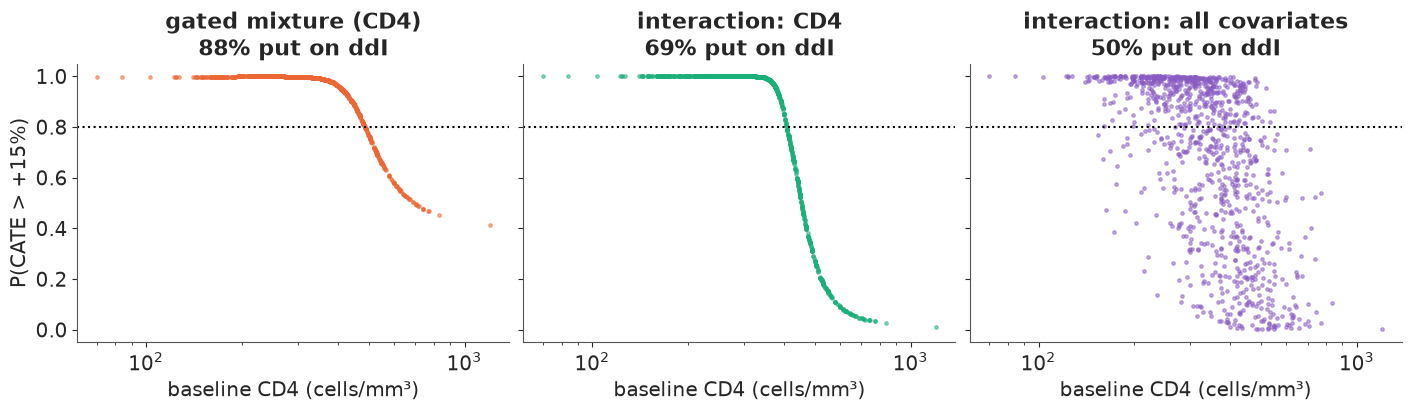

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
for ax, p, (name, share), col in zip(axes, [p_mix, p_int["cd4"], p_int["all"]], shares.items(), [ORANGE, AQUA, PURPLE]):
    ax.scatter(df.cd40, p, s=6, alpha=0.5, color=col)
    ax.axhline(CONFIDENCE, color="k", ls=":")
    ax.set(xscale="log", xlabel="baseline CD4 (cells/mm³)", title=f"{name}\n{100 * share:.0f}% put on ddI")
axes[0].set_ylabel("P(CATE > +15%)");

In [30]:
rows = {}
for name, p in [("gated mixture (CD4)", p_mix), ("interaction: CD4", p_int["cd4"]), ("interaction: all covariates", p_int["all"])]:
    out = p < CONFIDENCE
    rows[name] = {"left out": int(out.sum()), "lowest CD4 left out": df.cd40[out].min(), "median CD4 left out": np.median(df.cd40[out]),
                  "median CD4 treated": np.median(df.cd40[~out]), "lowest P": p.min().round(2),
                  "agrees with mixture": ((p >= CONFIDENCE) == (p_mix >= CONFIDENCE)).mean().round(3)}
pd.DataFrame(rows).T

,left out,lowest CD4 left out,median CD4 left out,median CD4 treated,lowest P,agrees with mixture
gated mixture (CD4),128.0,488.0,544.5,320.0,0.41,1.000
interaction: CD4,327.0,408.0,464.0,294.5,0.01,0.811
interaction: all covariates,527.0,154.0,408.0,280.5,0.00,0.609


In [31]:
assert h.check("task5", share_mixture=shares["gated mixture (CD4)"],
               share_interaction_cd4=shares["interaction: CD4"],
               share_interaction_all=shares["interaction: all covariates"])

- PASS `share_mixture` = 0.8782 is consistent with the reference solution.
- PASS `share_interaction_cd4` = 0.6889 is consistent with the reference solution.
- PASS `share_interaction_all` = 0.4986 is consistent with the reference solution.

**Three models, three answers.** The gated mixture puts close to 90% of patients on ddI, and
chain by chain the share moves by only a few points - the decision does not hinge on the
imperfect mixing of Task 4. The linear CD4 interaction puts about 70% on ddI, the regression
with every interaction about half. All three leave out mainly patients with a *high* baseline
CD4 - that much is agreed. They disagree for two different reasons.

- **Shape at high CD4.** The linear interaction's CATE falls in a straight line in log CD4,
  with a band that stays narrow, so for the highest counts it is confident of little or no
  benefit (its lowest probability is near 0). The mixture's CATE falls more gently above about
  400 cells and its band opens up at the edge, where few patients inform it (Task 4 figure), so
  its probabilities decline slowly and nobody's drops much below 0.4. The linear model's
  confidence at the edge comes from its functional form, not from data.
- **Number of modifiers.** With every covariate interacted, each patient's CATE carries the
  uncertainty of twelve interaction coefficients, so fewer patients clear an 80% bar even
  though most of those coefficients are near zero. Three of them (age, non-white, injection
  drug use) have 89% intervals that exclude zero - with twelve tries, one or two would by
  chance. **A rule of the form "P > 0.8" rewards models that claim less heterogeneity.**

Which shape is right at high CD4? Randomisation makes every CD4 band a small trial of its own,
so a model-free referee is simply the difference in mean log change between the arms per band:

In [32]:
bands_q = pd.qcut(df.cd40, 4).to_numpy()
g = pd.DataFrame({"change": change, "arm": t, "band": bands_q}).groupby(["band", "arm"], observed=True)["change"]
cate_int_cd4 = fits_int["cd4"].posterior["cate"].mean(("chain", "draw")).to_numpy()
raw = pd.DataFrame({"raw difference": g.mean().unstack()[1] - g.mean().unstack()[0],
                    "se": np.sqrt((g.var() / g.size()).unstack().sum(axis=1)),
                    "gated mixture": pd.Series(cate_mean).groupby(bands_q, observed=True).mean(),
                    "interaction: CD4": pd.Series(cate_int_cd4).groupby(bands_q, observed=True).mean()})
raw.round(3)

,raw difference,se,gated mixture,interaction: CD4
"(69.999, 265.0]",0.318,0.051,0.262,0.290
"(265.0, 340.0]",0.129,0.039,0.206,0.219
"(340.0, 424.5]",0.236,0.038,0.180,0.174
"(424.5, 1199.0]",0.131,0.041,0.158,0.119


The raw differences are noisy (standard errors of about 0.04-0.05) and not even monotone - the
second quartile's benefit is smaller than the third's - but they confirm the main pattern, a
larger relative benefit in the lowest quartile, and they cannot choose between the two
shapes in the top quartile: both models' averages there are within about one standard error of
the raw estimate. Whether ddI clears 15% for patients above about 450 cells is genuinely
uncertain, and it is exactly where the models disagree.

**Recommendation to the clinic.**
1. *There is no evidence of a subgroup of non-responders.* The "responder" split came from
   looking at the outcome. Models that use only baseline information find no subgroup with an
   effect near zero, except the linear interaction extrapolated to the highest CD4 counts,
   where there are few patients.
2. *The relative benefit shrinks as baseline CD4 rises.* Under your 15% / 80% rule, patients
   with a low or middling baseline count qualify under both CD4 models (see the "lowest CD4
   left out" column). Above that, the verdict depends on modelling choices the data cannot
   settle; the expected gain is still positive, so the decision rests on how much the patient
   fears the toxicity. The all-covariate model's longer list of exclusions is mostly the price
   of its twelve uncertain interaction terms, not evidence against ddI.
3. *What this cannot tell you.* A 20-week CD4 count is a surrogate, not survival; the effect
   modification is on the relative scale (a smaller percentage of a larger count can be a
   similar number of cells); and CD4 as the modifier and the 15% threshold both deserve a
   second trial before they become policy.
4. *The subgroups the mixture found are real but mostly prognostic:* a volatile minority whose
   CD4 counts drop or jump, in both arms. They matter for monitoring, much less for choosing
   the drug.

## Going further

- **Profile regression proper.** Instead of a gate, model the covariates jointly with the
  outcome inside each subgroup (Molitor et al. 2010, the R package PReMiuM): subgroups are then
  defined by covariate *profiles*, and membership of a new patient follows from Bayes' rule.
  Does it route the thin corners of covariate space better than the gate with every covariate?
- **All four arms.** Give each subgroup a vector of three treatment effects (ZDV + ddI,
  ZDV + zalcitabine, ddI alone) and ask which regimen to choose for whom.
- **Change of scale.** Refit on the raw CD4 scale (with a variance model). Does effect
  modification by baseline CD4 survive, reverse, or vanish? What does that say about the
  clinic's "15%" rule?
- **A clinical endpoint.** `time` and `cid` give time to AIDS or death. Build a mixture of
  survival regressions and see whether the prognostic subgroup of Task 2 predicts events.

In [33]:
h.progress()

**C11**: 0/17 hints used, 11/11 checks passed.